# A/B Test Design and Results Analysis — Recommendation Algorithm

## Business Context

I worked as a product analyst for a company building an entertainment app
with an "infinite feed" feature, similar to short-video apps. The app has
two monetization models: a monthly paid subscription (ad-free feed), and
ads shown to users who haven't subscribed.

The recommendation systems team developed a new recommendation algorithm,
expected to surface more engaging content for each user. My task was to
design the A/B test needed to validate this hypothesis, monitor it while
running, and analyze the results.



## Data

Three datasets were used:

- `sessions_project_history.csv` — historical session data covering
  2025-08-15 to 2025-09-23.
- `sessions_project_test_part.csv` — data from the first day of the A/B
  test (2025-10-14).
- `sessions_project_test.csv` — data for the full test period
  (2025-10-14 to 2025-11-02).

All three share the same structure, differing only in the time period
covered.

**Columns:**
- `user_id` — user ID
- `session_id` — session ID
- `session_date` — session date
- `session_start_ts` — session start date and time
- `install_date` — app install date
- `session_number` — sequential session number for the user
- `registration_flag` — whether the user is registered
- `page_counter` — number of pages viewed during the session
- `region` — user's region
- `device` — user's device type
- `test_group` — A/B test group (not present in the historical dataset)

## Project Scope
Calculate the test design parameters, monitor the test for correctness
while it runs, and analyze the final results.



## 1. Historical Data (EDA)


### 1.1. Loading Historical Data
Loaded the historical session data (`sessions_project_history.csv`) into a dataframe and reviewed the first rows.


In [5]:
# Import library for analysis
import pandas as pd

url = 'https://code.s3.yandex.net/datasets/'
# Load data into dataframes
sessions_history = pd.read_csv(f'{url}sessions_project_history.csv')

In [6]:
# Display info about the dataframe
sessions_history.info()

# Display the first rows of the dataframe
sessions_history.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


### 1.2. Getting Familiar with the Data
Calculated the number of unique sessions per user, then inspected the full session history for the single most active user to understand how each column behaves over time.


In [8]:
# Calculate the number of unique sessions per user
user_per_session = sessions_history.groupby('user_id')['session_id'].nunique().reset_index().sort_values('session_id', ascending=False)

user_per_session.head(3)

,user_id,session_id
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9


In [9]:
# Display the data for the user with the most sessions
display(sessions_history[sessions_history['user_id'] == '10E0DEFC1ABDBBE0'])

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


**Observations for the most active user (user_id: 10E0DEFC1ABDBBE0):**
- Active almost every day in August
- Always accessed the app from an Android device
- No registration progress — never registered during the observed period
- Viewed up to 4 pages on the first day, then engagement dropped except for one day (2025-08-14) — possibly driven by a content promotion that day


### 1.3. Registration Trend
Registered user count is one of the most important product metrics. Aggregated the historical data by day (assuming at most one session and a stable registration status per user per day) and visualized the daily trend in both total and registered users, plus the daily registration share.


In [12]:
# Convert data type to datetime64[ns]
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'], errors='coerce')

# Aggregate the data
daily_stats = sessions_history.groupby('session_date').agg(
    unique_users=('user_id', 'nunique'),          
    reg_sum=('registration_flag', 'sum')).reset_index()

display(daily_stats)

,session_date,unique_users,reg_sum
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


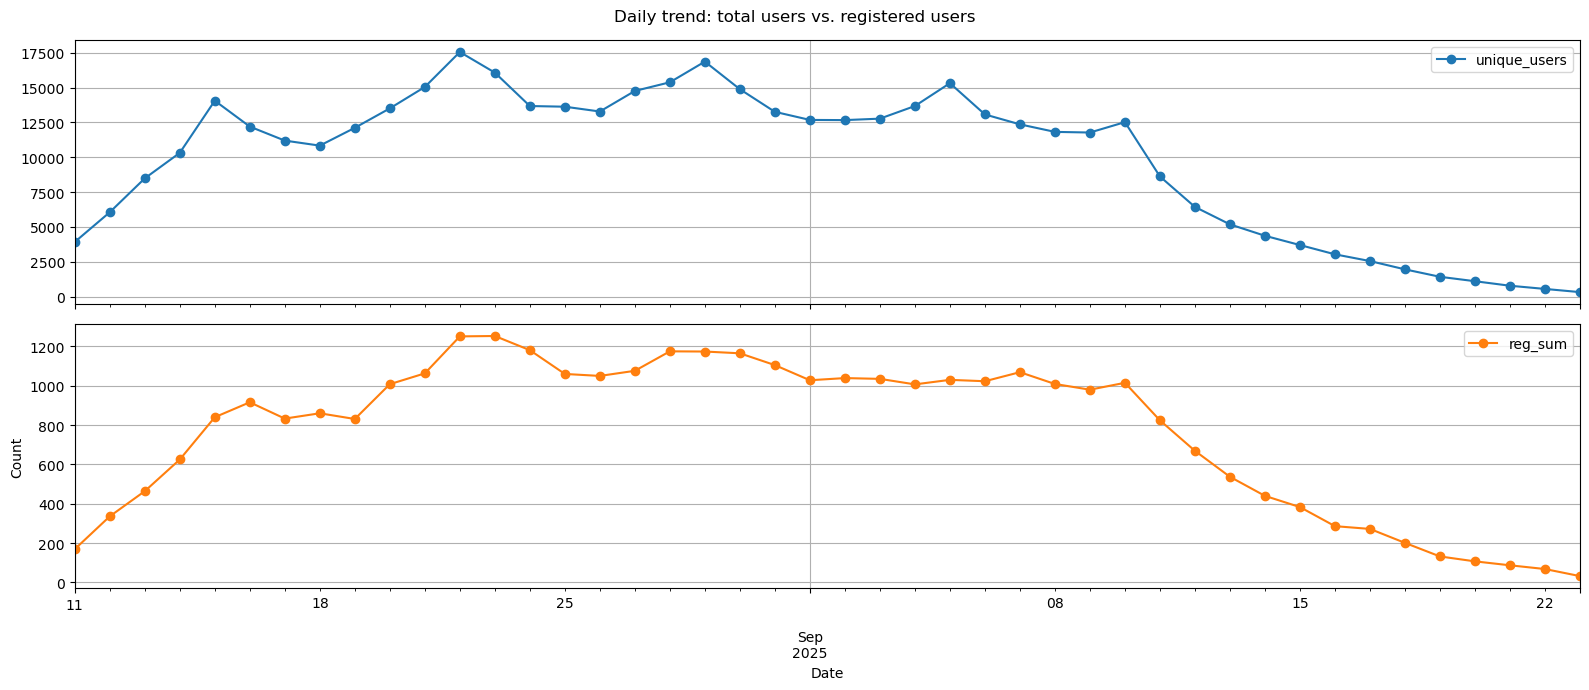

In [13]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Build a line chart
axes = daily_stats.plot(kind='line',
                x='session_date',
                y=['unique_users', 'reg_sum'],
                subplots=True,
                sharex=True,
                sharey=False,
                marker='o',
                figsize=(16, 7),
                title='Daily trend: total users vs. registered users')

plt.xlabel('Date')
plt.ylabel('Count')
axes[0].grid()
axes[1].grid()
plt.tight_layout()

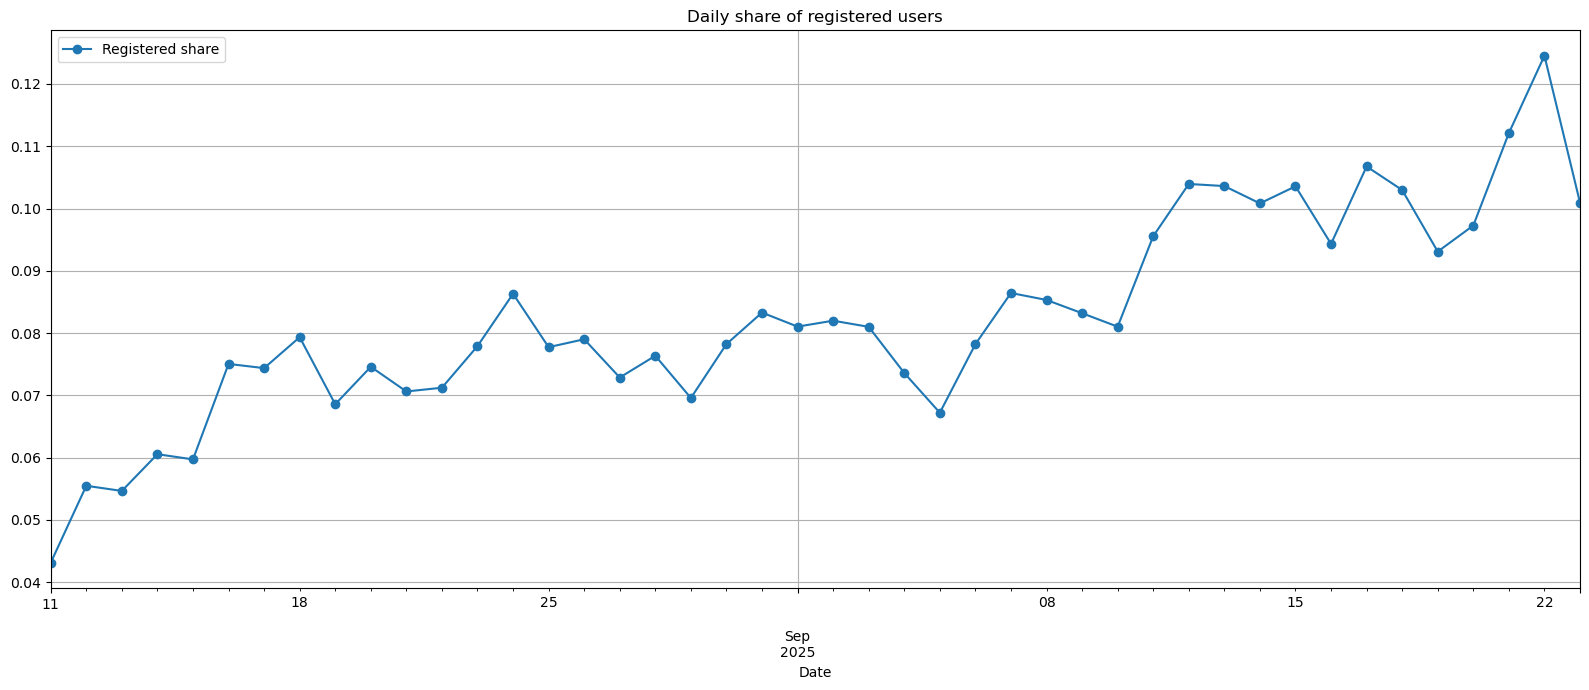

In [14]:
# Build a separate line chart of the daily registered-user share

# Build a pivot table
users_reg = sessions_history.pivot_table(index='session_date', columns='registration_flag', values='user_id', aggfunc='nunique').reset_index()

# Rename the columns
users_reg.columns = ['session_date', 'non_reg_users', 'reg_users']

# Calculate total users and the registered-user share
users_reg['total_users'] = users_reg['non_reg_users'] + users_reg['reg_users']
users_reg['share'] = users_reg['reg_users'] / users_reg['total_users']

# Build a line chart
users_reg.plot(kind='line',
              x='session_date',
              y='share',
              figsize=(16, 7),
              marker='o',
              label='Registered share')


plt.title('Daily share of registered users')
plt.xlabel('Date')
plt.ylabel('')
plt.grid()
plt.tight_layout()

### 1.4. Pages Viewed per Session
Another key product metric: number of pages viewed per session — a proxy for content engagement, and by extension, likelihood to register and subscribe. Counted sessions by number of pages viewed and visualized the distribution as a bar chart.


,page_counter,session_date
0,1,29160
1,2,105536
2,3,166690
3,4,105569
4,5,26288
5,6,2589
6,7,92


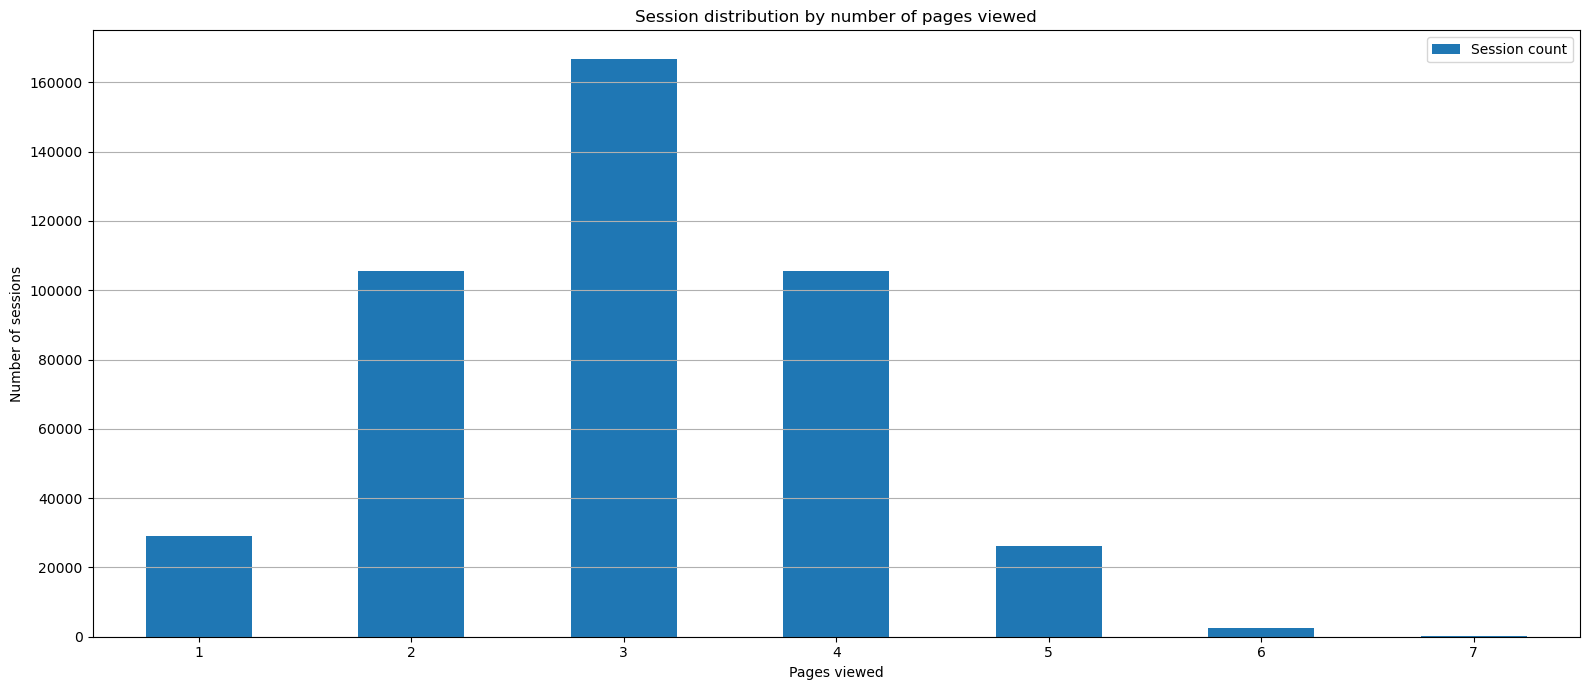

In [16]:
# Group by number of sessions per page count
session_count = sessions_history.groupby('page_counter')['session_date'].count().reset_index()
display(session_count)

# Build a bar chart
axes = session_count.plot(kind='bar',
                   x='page_counter',
                   y='session_date',
                   figsize=(16, 7),
                   rot=0,
                   label='Session count')

# Label the values on the chart
# axes.bar_label(axes.containers[0], fontweight='bold', fontsize=12, padding=2)

plt.title('Session distribution by number of pages viewed')
plt.xlabel('Pages viewed')
plt.ylabel('Number of sessions')
plt.tight_layout()
plt.grid(axis='y')

### 1.5. Share of Highly Engaged Sessions
The product team treats sessions with 4+ pages viewed as a signal of content satisfaction and recommendation quality — an important proxy metric. Created a `good_session` flag (1 if 4+ pages viewed, 0 otherwise) and plotted the daily share of good sessions across the full observation period.


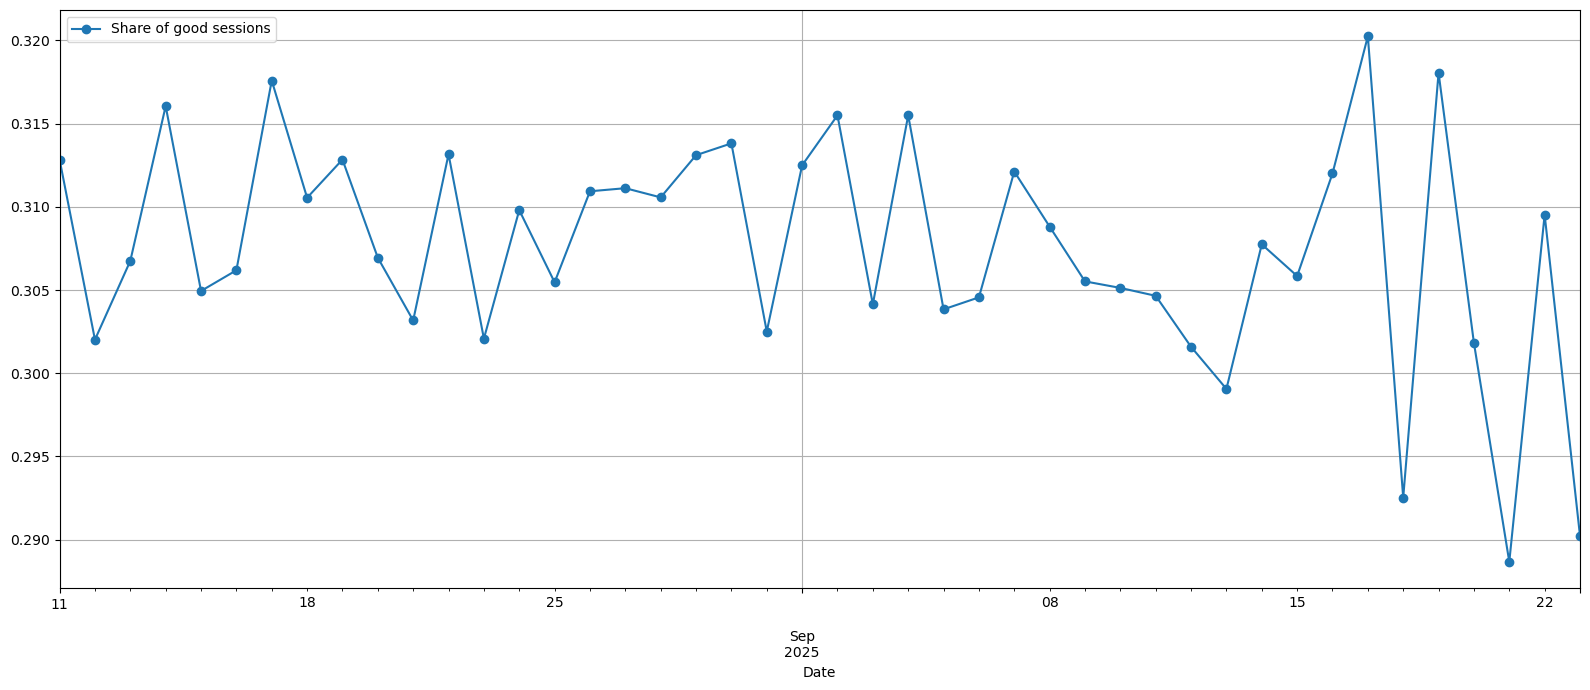

In [18]:
# Create an additional column
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Group the data to find the daily share of good sessions
good_for_total = sessions_history.groupby('session_date')['good_session'].agg(
    total_sessions='count',
    good_sessions='sum').reset_index()

# Calculate the share
good_for_total['share'] = good_for_total['good_sessions'] / good_for_total['total_sessions']

good_for_total.plot(kind='line',
                   x='session_date',
                   y='share',
                   figsize=(16, 7),
                   marker='o',
                   label='Share of good sessions')

plt.xlabel('Date')
plt.ylabel('')
plt.tight_layout()
plt.grid()

## 2. Test Design

Designing the test required:
- Choosing the target metric
- Calculating the required sample size
- Calculating the required test duration given current traffic levels


### Target Metric
**Average number of pages viewed per session.**

This metric directly reflects user engagement with the product — if the new recommendation algorithm performs better, users should view more pages per session.


### 2.1. Sample Size Calculation
Calculated the required sample size per group using `NormalIndPower.solve_power()` from `statsmodels.stats.power`, with:
- Significance level: 0.05
- Type II error probability: 0.2
- Test power: 0.8
- Minimum detectable effect (MDE): 3%


In [22]:
from statsmodels.stats.power import NormalIndPower

# Set parameters
alpha = 0.05  # Significance level
beta = 0.2  # Type II error probability (1 - power)
power = 0.8  # Test power
mde = 0.03  # Minimum detectable effect

# Initialize the NormalIndPower class
power_analysis = NormalIndPower()

# Calculate the sample size
sample_size = power_analysis.solve_power(
    effect_size = mde,
    power = power,
    alpha = alpha,
    ratio = 1 # Equal allocation between samples
)

print(f"Required sample size per group: {int(sample_size)}")

Required sample size per group: 17441


### 2.2. Test Duration Calculation
Used the required sample size and the average daily user count from the historical data to calculate the minimum test duration (sample size ÷ average daily traffic, rounded up).


In [24]:
from math import ceil

# Average daily app users, based on historical data
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Calculate test duration in days as sample size divided by average daily users
test_duration = ceil(2 * sample_size / avg_daily_users)

print(f"Calculated A/B test duration at current traffic of {avg_daily_users} users/day: {test_duration} days")

Calculated A/B test duration at current traffic of 9907.363636363636 users/day: 4 days


## 3. A/B Test Monitoring


### 3.1. Group Distribution Check
The A/B test launched successfully, with data available for the first
few days. Before trusting any results, I first confirmed users were
split correctly and metrics were tracking as expected: loaded
`sessions_project_test_part.csv`, calculated the number of unique users
per group for one day of observation, and computed the percentage
difference between groups A and B using:

$$P = 100 \cdot \frac{|A - B|}{A}$$


test_group,session_date,A,B
0,2025-10-14,1477,1466


Group A: 1477 users
Group B: 1466 users
Percentage difference: 0.7448


Text(0.5, 0.9, 'Difference: 0.74')

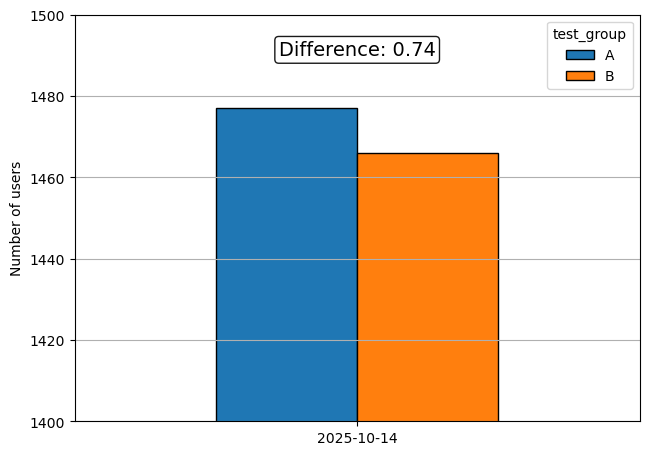

In [27]:
# Load data into dataframes
sessions_test_part = pd.read_csv(f'{url}sessions_project_test_part.csv')

# Build a pivot table
group_per_users = sessions_test_part.pivot_table(
    index='session_date', 
    columns='test_group', 
    values='user_id', 
    aggfunc='nunique').reset_index()

display(group_per_users)

A = group_per_users.loc[0, 'A']
B = group_per_users.loc[0, 'B']
p = round(100 * abs(A - B) / A, 4)

print(f"Group A: {A} users")
print(f"Group B: {B} users")
print(f"Percentage difference: {p}")

# Build a bar chart to visualize the difference between groups
axes = group_per_users.plot(kind='bar',
                    x='session_date',
                    y=['A', 'B'],
                    rot=0,
                    edgecolor='black')

# Label the values on the chart
# axes.bar_label(axes.containers[0], fontweight='bold', fontsize=12, padding=2)
# axes.bar_label(axes.containers[1], fontweight='bold', fontsize=12, padding=2)

plt.tight_layout()
plt.ylim(1400, 1500)
plt.ylabel('Number of users')
plt.xlabel('')
plt.grid(axis='y')


plt.annotate(f'Difference: {p:.2f}',
    xy=(0.5, 0.9),
    xycoords='axes fraction',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.9),
    ha='center', 
    fontsize=14)

### 3.2. Checking for User Overlap
Beyond confirming similar group sizes, it's important to confirm the groups are independent — i.e. no user appears in both A and B simultaneously. Checked for any users present in both groups at once.


In [29]:
users_group = sessions_test_part.groupby('user_id')['test_group'].nunique().reset_index()

# Check whether any users appear in both groups at once
repeat_users = users_group[users_group['test_group'] > 1]

if repeat_users.shape[0] == 0:
    print('No users found in both groups.')
else:
    print(f'Found {repeat_users.shape[0]} users present in both groups.')

No users found in both groups.


### 3.3. Device Distribution Balance
Also worth confirming: users are evenly distributed across categorical variables like device type and region. Built two charts comparing the device-type share for groups A and B.


,test_group,device,user_id,total_users,share
0,A,Android,656,1477,0.44
1,A,Mac,156,1477,0.11
2,A,PC,369,1477,0.25
3,A,iPhone,296,1477,0.20
4,B,Android,668,1466,0.46
5,B,Mac,148,1466,0.10
6,B,PC,381,1466,0.26
7,B,iPhone,269,1466,0.18


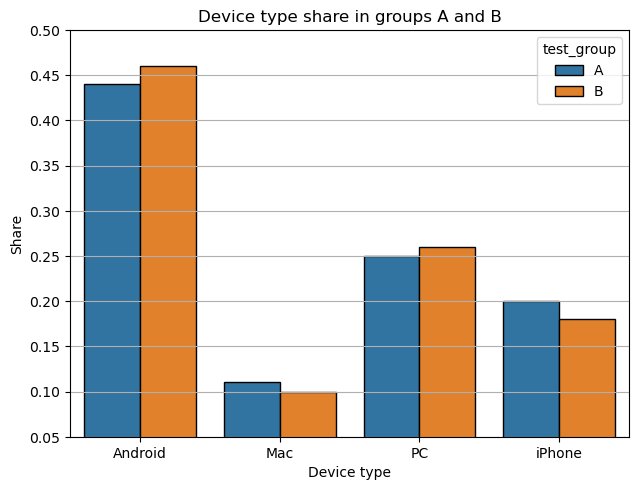

In [31]:
device_group_count = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index()

users_all = device_group_count.groupby('test_group')['user_id'].sum()

# Calculate the share of each device type
device_group_count['total_users'] = device_group_count['test_group'].map(users_all)
device_group_count['share'] = round(device_group_count['user_id'] / device_group_count['total_users'], 2)

display(device_group_count)

axes = sns.barplot(data=device_group_count,
            x='device',
            y='share',
            hue='test_group',
            edgecolor='black')

# Label the values on the chart
# axes.bar_label(axes.containers[0], fontweight='bold', fontsize=12, padding=2)
# axes.bar_label(axes.containers[1], fontweight='bold', fontsize=12, padding=2)

plt.tight_layout()
plt.ylim(0.05, 0.5)
plt.xlabel('Device type')
plt.ylabel('Share')
plt.title('Device type share in groups A and B')
plt.grid(axis='y')

### 3.4. Regional Distribution Balance
Same check for region — built two charts comparing the regional share for groups A and B, using a different chart type than the device breakdown.


,test_group,region,user_id,total_users,share
0,A,CIS,644,1477,0.44
1,A,EU,224,1477,0.15
2,A,MENA,609,1477,0.41
3,B,CIS,645,1466,0.44
4,B,EU,217,1466,0.15
5,B,MENA,604,1466,0.41


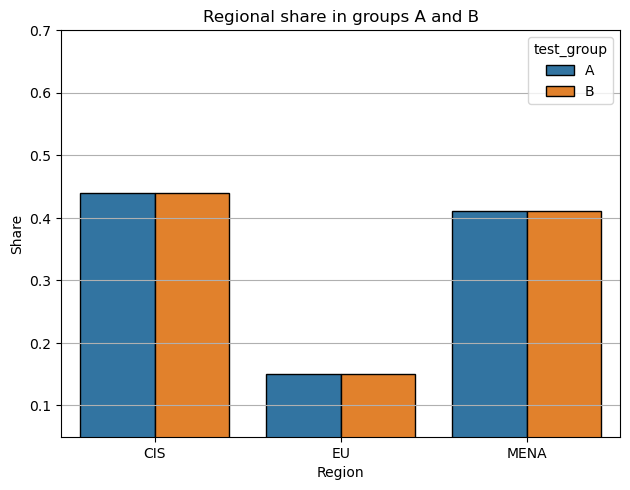

In [33]:
region_group_count = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().reset_index()

users_all_region = region_group_count.groupby('test_group')['user_id'].sum()

# Calculate the share of each device type
region_group_count['total_users'] = region_group_count['test_group'].map(users_all_region)
region_group_count['share'] = round(region_group_count['user_id'] / region_group_count['total_users'], 2)

display(region_group_count)

axes = sns.barplot(data=region_group_count,
            x='region',
            y='share',
            hue='test_group',
            edgecolor='black')

# Label the values on the chart
# axes.bar_label(axes.containers[0], fontweight='bold', fontsize=12, padding=2)
# axes.bar_label(axes.containers[1], fontweight='bold', fontsize=12, padding=2)

plt.tight_layout()
plt.ylim(0.05, 0.7)
plt.xlabel('Region')
plt.ylabel('Share')
plt.title('Regional share in groups A and B')
plt.grid(axis='y')

### 3.5. Monitoring Conclusion
Summary of the pre-launch health check on the running test — user count balance, group independence (overlap check), and distribution balance across device and region.


### Monitoring Conclusion

**Was there a difference in user counts between the two groups?**
Yes — a difference of 11 users between groups A and B, a relative
difference of 0.74%. This gap is small enough not to be a concern.

**Are the samples independent? Was any user overlap found between test
and control groups?**
No overlap was found — no user appeared in both group A and group B
simultaneously.

**Is the distribution of users balanced across device type and region?**
Device distribution shows some variation: most users are on Android
(A=0.44, B=0.46, a 0.02 gap), followed by PC (A=0.25, B=0.26, a 0.01
gap), and Mac has the fewest users with the smallest gap (A=0.11,
B=0.10, a 0.01 gap). Regional distribution is much more balanced — all
three regions show near-identical shares across groups A and B, with
CIS being the largest region (A=0.44, B=0.44).


## 4. A/B Test Results

The test concluded, with results available for the full experiment period. Next: confirm the test ran correctly, then interpret the results.


### 4.1. Loading Results and Computing the Core Metric
Loaded `sessions_project_test.csv` and created the `good_session` flag (1 if 4+ pages viewed, 0 otherwise), matching the definition used during the historical analysis.


In [38]:
# Load data into dataframes
sessions_test = pd.read_csv(f'{url}sessions_project_test.csv')

# Create an additional column
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

# Check the values
sessions_test.head(7)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
5,31F7A42B32103403,E9B64B779C3348ED,2025-10-20,2025-10-20 17:09:41,2025-10-19,2,0,2,CIS,PC,B,0
6,87C09E3E3B334959,FECFF83C13DC9364,2025-10-22,2025-10-22 23:51:42,2025-10-20,3,0,4,CIS,iPhone,B,1


### 4.2. Validity Check
Before analyzing the core product metrics, confirmed the two groups being compared are genuinely comparable: calculated unique daily sessions for each group, then used a statistical test to check whether any difference in daily session counts was statistically significant.


In [40]:
# Calculate the number of unique sessions
session_count = sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique().reset_index()

display(session_count)

,session_date,test_group,session_id
0,2025-10-14,A,1502
1,2025-10-14,B,1628
2,2025-10-15,A,2235
3,2025-10-15,B,2283
4,2025-10-16,A,3280
5,2025-10-16,B,3241
6,2025-10-17,A,4089
7,2025-10-17,B,4054
8,2025-10-18,A,5013
9,2025-10-18,B,5059


In [41]:
# Check whether unique daily session counts differ between the two samples, or whether any difference is not statistically significant
# Use a statistical test to assess whether the two sample means are equal

# Extract the data for groups A and B
sessions_a = session_count[session_count['test_group'] == 'A']['session_id']
sessions_b = session_count[session_count['test_group'] == 'B']['session_id']

# Import scipy.stats for the Mann-Whitney U test
from scipy.stats import mannwhitneyu

# Run the Mann-Whitney U test
u_stat, p_value = mannwhitneyu(sessions_a, sessions_b, alternative='two-sided')

alpha = 0.05

if p_value > alpha:
    print(f'pvalue={p_value} > {alpha}')
    print('Difference is not significant!')
else:
    print(f'pvalue={p_value} < {alpha}')
    print('Difference is significant!')

pvalue=0.8817307917391243 > 0.05
Difference is not significant!


### 4.3. Comparing the Share of Good Sessions
With test validity confirmed, moved on to the core metric — the share of good sessions. Calculated this share for groups A and B, along with the difference between them.


In [43]:
success_rates = sessions_test.groupby('test_group')['good_session'].mean().reset_index()

rate_a = success_rates[success_rates['test_group'] == 'A']['good_session'].iloc[0]
rate_b = success_rates[success_rates['test_group'] == 'B']['good_session'].iloc[0]
# Calculate the difference
rate_diff = rate_b - rate_a
# Percentage difference
p = round(100 * abs(rate_a - rate_b) / rate_a, 4)


print(f"Group A: {rate_a:.4f} share of good sessions")
print(f"Group B: {rate_b:.4f} share of good sessions")
print(f"Difference in share of good sessions: {rate_diff:.4f}")
print(f"Percentage difference: {p:.2f}%")

Group A: 0.3077 share of good sessions
Group B: 0.3183 share of good sessions
Difference in share of good sessions: 0.0106
Percentage difference: 3.43%


### 4.4. Statistical Significance of the Effect
The test group showed a share of good sessions roughly 1.1% higher than control — but that alone isn't enough to act on. Ran a statistical test to determine whether this difference in the good-session-share metric is statistically significant (significance level: 0.05).


In [45]:
from statsmodels.stats.proportion import proportions_ztest

success_a = sessions_test[sessions_test['test_group']=='A']['good_session'].sum()
success_b = sessions_test[sessions_test['test_group']=='B']['good_session'].sum()

total_a = len(sessions_test[sessions_test['test_group']=='A'])
total_b = len(sessions_test[sessions_test['test_group']=='B'])

stat_ztest, p_value_ztest = proportions_ztest(
    count=[success_a, success_b],
    nobs=[total_a, total_b],
    alternative='two-sided'
)

print('Statistical results (z-test):')
print(f'* z-statistic: {stat_ztest:.4f}')
print(f'* p-value: {p_value_ztest:.4f}')

Statistical results (z-test):
* z-statistic: -3.6027
* p-value: 0.0003


### 4.5. Final Conclusion
Summary of the experiment for the app development team — experiment scale and duration, whether the new algorithm moved the core metric, the resulting p-value, and a recommendation.


### Final Conclusion

The test ran for **4 days**, with an average daily traffic of **9,907
users**. Group A included **1,477 users**, group B included **1,466
users**, with no overlap between the groups.

The new recommendation algorithm produced a meaningful increase in the
share of good sessions:

- **Absolute uplift: +1.06%** (from 30.77% to 31.83%)
- **Relative uplift: +3.43%**
- **Statistical significance: p-value = 0.0003** — well below the 0.05
  significance threshold, so the uplift is statistically significant.

**Recommendation: roll out the new algorithm.**
- The improvement is statistically confirmed
- Risk is minimal — no negative impact was observed on baseline metrics

To manage rollout risk, I'd suggest a gradual release (20–50% of
traffic) with continued monitoring of key metrics over the following
weeks before a full rollout.
